# alternating soundsource analysis

In [1]:
from workbench.data.preprocess import  combTableCreate, expand_dict_columns
from workbench.plotting import serve_cell_dashboard
import numpy as np
import pandas as pd
import polars as pl
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import panel as pn
from scipy.stats import friedmanchisquare, wilcoxon, false_discovery_control
import itertools

In [2]:
conn = sqlite3.connect(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\Recordings_FH.db")
sql = """
SELECT * FROM Recordings WHERE (Animal_Id, Cell_Id) IN (
SELECT Animal_Id, Cell_Id FROM Recordings WHERE Condition IN ("Baseline", "soso") GROUP BY Animal_Id, Cell_Id 
HAVING COUNT(DISTINCT Condition) >= 2) 
AND Condition IN ("Baseline","soso") AND use = 1 AND Folders_generated = 1
"""

datatable= pd.read_sql_query(sql, conn)
conn.close()

In [3]:
try:
    comb_table = pl.read_parquet(Path(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\comb_tables\soso_comb.parquet"))
except:
    print('comb_table doesnt exist, start creation')
    comb_table = combTableCreate(datatable, "", "")
    comb_df = pd.DataFrame(comb_table)
    dict_list = [ 'pupil_psth', 'whisk_psth', 'eye_psth']
    comb_df = expand_dict_columns(
        comb_df,
        dict_columns=dict_list,
        flatten_2d=False
    )
    # clean and reshape the dataframe
    comb_table = pl.from_dataframe(comb_df)
    conditions = comb_table['Condition'].unique().to_list()

    comb_a = (
        comb_table.filter(pl.col("Condition") == conditions[0]).drop("Condition")
    )
    comb_b = (
        comb_table.filter(pl.col("Condition") == conditions[1]).drop("Condition")
    )

    comb_joined = comb_a.join(
        comb_b,
        on=['Animal_Id', 'Cell_Id'],
        how="inner"
    )

    comb_joined = comb_joined[[s.name for s in comb_joined if not (s.null_count() == comb_joined.height)]]
    comb_table = comb_joined.rename(lambda c: c[:-6] if c.endswith("_right") else c)
    comb_table.write_parquet(r"Z:\lab share\Data\Florian\comb_tables\soso_comb.parquet", use_pyarrow=True)
    print("table created and saved")

comb_table doesnt exist, start creation
----------------------------------------------------------------------------------------------------
Animal_Id FH8soso; Cell_Id 4, Baseline being processed
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Animal_Id FH8soso; Cell_Id 4, soso being processed
----------------------------------------------------------------------------------------------------
\\172.25.250.112\burgalossi\lab share\Data\Florian\ADN\FH8Soso\analysis\Data4\soso\exp_data.mat
----------------------------------------------------------------------------------------------------
Animal_Id FH8soso; Cell_Id 6, Baseline being processed
----------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------

In [4]:
# analysis
speaker_position = {
    'a': 93,
    'w': 178,
    'e': 272,
    'r': 356
}
rads_x = np.cos(np.deg2rad(list(speaker_position.values())))
rads_y = np.sin(np.deg2rad(list(speaker_position.values())))
#returned_degs = np.degrees(np.arctan2(rads_y, rads_x))
#returned_degs = (returned_degs+360)%360


For the analysis i should start with per recording representation of activity per speaker position. What about Rasterplots stacked on top of each other (4), each corresponding to a different speaker.
For now this will happen for all recordings individually before analysis across all follows

In [5]:
# cell by cell sound source representation

half_window = 1500 # in ms
time_bin = 0.002
nbins = int(np.round(half_window/(time_bin*1000)))
raster_edges = np.linspace(-half_window, half_window, nbins*2+1)

# mimic the medfilt1
bins_plot = np.concatenate(
    [[raster_edges[0]],
      np.median(
          np.vstack( # create a 2d array with the raster edges shifted by 1 each. the median then picks the value right in between them
              [raster_edges[:-1],
                raster_edges[1:]]
                )
            , axis=0)
    ]
)
bins_plot = bins_plot[1::]
resp_window = np.flatnonzero(
        (bins_plot > 1) & (bins_plot < 300)
        )

raster_times = comb_table['RasterTimes']
raster_rows = comb_table['RasterRows']
raster_rate = comb_table['RasterRate']
HDRateSmooth = comb_table['hdRateSmooth']
DIRECTIONS = np.linspace(0, 360, 37)
stim_keys = raster_times[0].keys()
trigger_time = comb_table['trigger_time'][0]
whisk_avg = comb_table['whisk_avg']
new_rate = np.zeros((len(raster_times), len(raster_edges)-1, len(stim_keys)))


In [6]:

for i in range(len(raster_times)):
    for idx, j in enumerate(stim_keys):
        if not len(raster_times[i][j]) == 0:
            counts, _ = np.histogram(raster_times[i][j], bins=raster_edges)
            new_rate[i, :, idx] = np.divide(counts, (np.max(raster_rows[i][j])*time_bin))

# construct whisking
#with PdfPages(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\soundsource_switching\individuals.pdf") as pdf:
speakers = ["a", "w", "e", "r"]
speaker_position = {
    "a": 93,
    "w": 178,
    "e": 272,
    "r": 356,
}

# Your mosaic layout (4 rows × 4 columns)
layout = [
    ["r_a", "psth_a", "line_a", "polar"],
    ["r_w", "psth_w", "line_w", "info"    ],
    ["r_e", "psth_e", "line_e", "info"    ],
    ["r_r", "psth_r", "line_r", "."    ],
]


# ─────────────────────────────────────────────────────────────
#  MAIN LOOP: one page per cell
# ─────────────────────────────────────────────────────────────
with PdfPages(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\figures\soso_indiv_cells.pdf") as pdf:
    for row_idx in range(len(raster_rate)):

        fig, axd = plt.subplot_mosaic(
            layout,
            figsize=(15, 12),
            gridspec_kw={"width_ratios": [2.5, 3, 3, 2.5]},
            empty_sentinel=".",       # treat "." cells as empty
        )

        # ----------------------------------------------------------
        # Convert the placeholder "polar" axis into a real polar axes
        # ----------------------------------------------------------
        polar_spec = axd["polar"].get_subplotspec()
        axd["polar"].remove()
        ax_polar = fig.add_subplot(polar_spec, projection="polar")

        # ----------------------------------------------------------
        # Loop over speakers and fill rasters, PSTHs, lineplots
        # ----------------------------------------------------------

        tmin, tmax = -100, 500   # example x-range (adjust as needed)

        for enum, key in enumerate(speakers):
            # Named axes from the mosaic
            ax_r = axd[f"r_{key}"]
            ax_p = axd[f"psth_{key}"]
            ax_l = axd[f"line_{key}"]

            # Set x-limits for all time-based axes
            for ax in (ax_r, ax_p, ax_l):
                ax.set_xlim(tmin, tmax)

            # ---------------- RASTER PLOT ----------------
            ax_r.scatter(
                raster_times[row_idx][key],
                raster_rows[row_idx][key],
                marker=".",
            )
            ax_r.set_ylabel(f"Speaker position {speaker_position[key]} [°]",fontsize=12, weight='bold')

            # ---------------- PSTH PLOT ------------------
            ax_p.bar(bins_plot, new_rate[row_idx, :, enum], width=time_bin*1000, align='edge', edgecolor='none')
            ax_p.set_ylabel("Firing Rate [Hz]")

            # ---------------- LINE PLOT ------------------
            ax_l.plot(trigger_time*1000, whisk_avg[row_idx][key])

        # ----------------------------------------------------------
        # Despine + tidy Cartesian axes
        # ----------------------------------------------------------

        def despine(ax):
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        for key in speakers:
            despine(axd[f"r_{key}"])
            despine(axd[f"psth_{key}"])
            despine(axd[f"line_{key}"])

            # Cleaner PSTH/line look (optional):
            #axd[f"psth_{key}"].tick_params(axis="y", left=False, labelleft=False)
            #axd[f"line_{key}"].tick_params(axis="y", left=False, labelleft=False)

        # ----------------------------------------------------------
        # POLAR PLOT: mark speaker angles & plot tuning (optional)
        # ----------------------------------------------------------

        angles_deg = list(speaker_position.values())
        labels     = list(speaker_position.keys())
        angles_rad = np.deg2rad(angles_deg)

        # Angle grid with labels a/w/e/r
        ax_polar.set_thetagrids(angles_deg, angles_deg)
        ax_polar.plot(np.deg2rad(DIRECTIONS), HDRateSmooth[row_idx])

        # Optional: put markers at those angles (radius = 1)
        ax_polar.scatter(angles_rad, np.ones(len(angles_rad)), s=40)

        # Optional tuning curve:
        # rate = np.array([...])   # length 4, matching angles_deg
        # ax_polar.plot(angles_rad, rate)

        ax_info = axd['info']
        ax_info.axis('off')
        infotext = f"""
                        Animal:      {comb_table['Animal_Id'][row_idx]}
                        Cell:        {comb_table['Cell_Id'][row_idx]}
                        PD:          {comb_table['HDAngle'][row_idx]:.2f}
                        PeakFR:      {comb_table['HDpeakFR'][row_idx]:.2f}
                        MeanFR:      {comb_table['HDFR'][row_idx]:.2f}
                        HDInx:       {comb_table['HDInx'][row_idx]:.2f}
                        pValR:       {comb_table['pValR'][row_idx]:.2f}
                        binsize:     {1000*time_bin:.2f} ms
                    """

        ax_info.text(0,1, infotext, va='top')
        # ----------------------------------------------------------
        # Final layout touch
        # ----------------------------------------------------------
        fig.tight_layout()

        # If saving to PDF:
        pdf.savefig(fig)
        plt.close(fig)
plt.show()

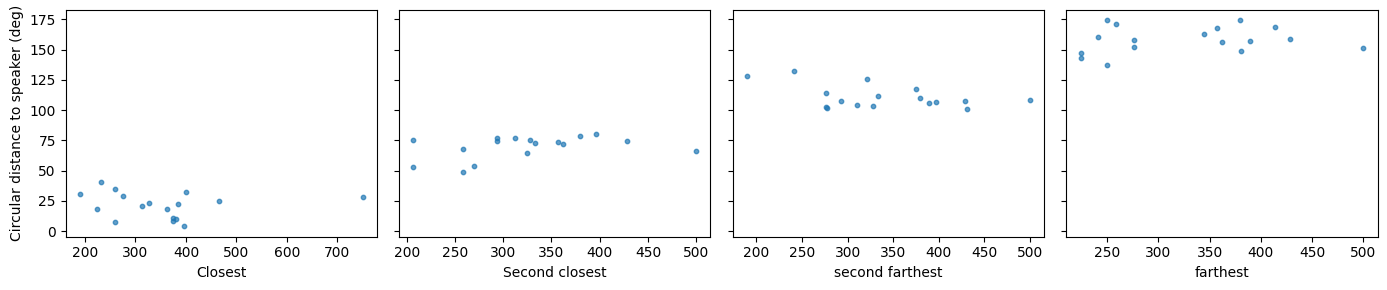

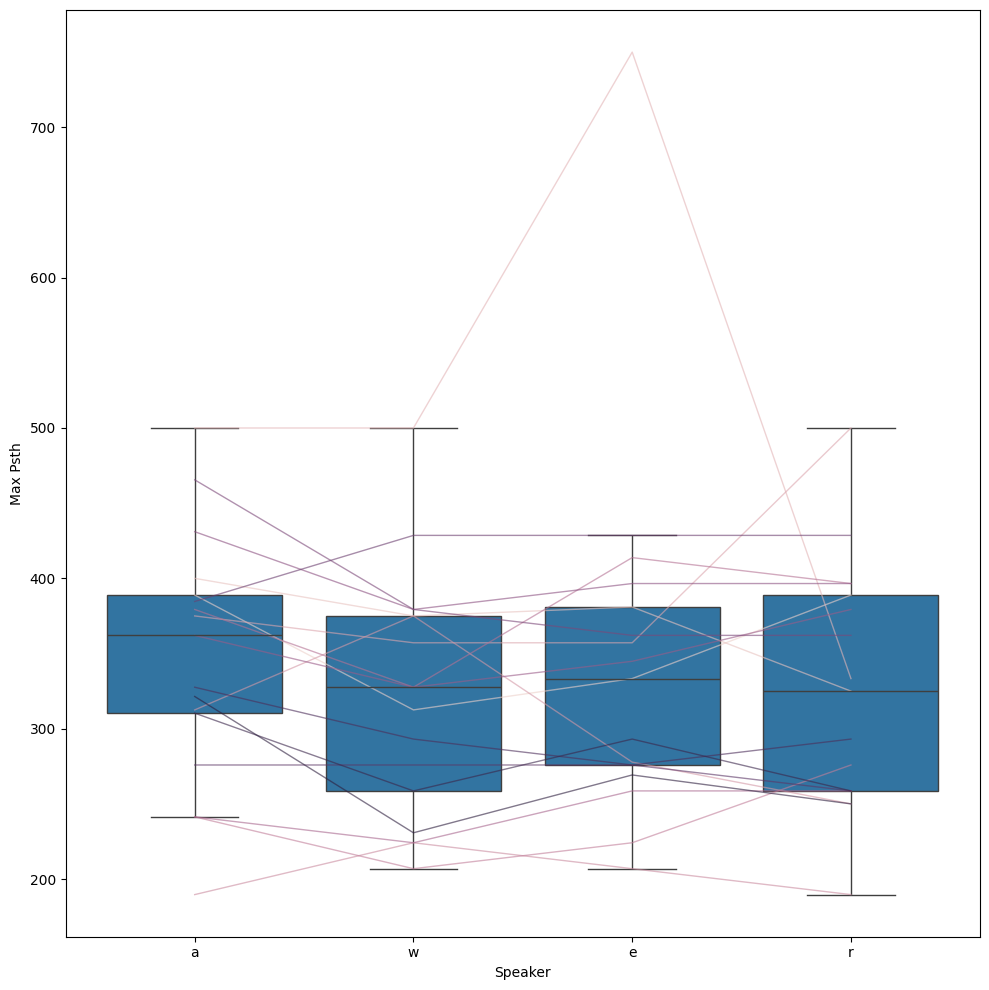

6.254901960784309 0.09984624650009775


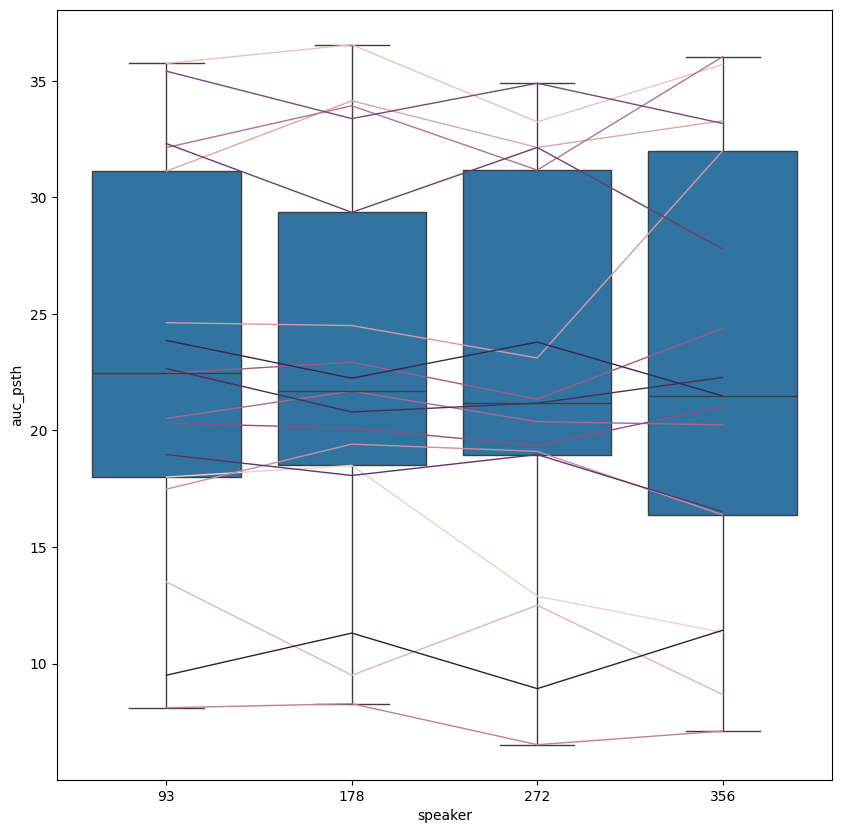

7.517647058823513 0.05710675306069067
93 vs 178: corrected p = 0.963226318359375
93 vs 272: corrected p = 0.077178955078125
93 vs 356: corrected p = 0.6878585815429688
178 vs 272: corrected p = 0.6740570068359375
178 vs 356: corrected p = 0.6878585815429688
272 vs 356: corrected p = 0.963226318359375


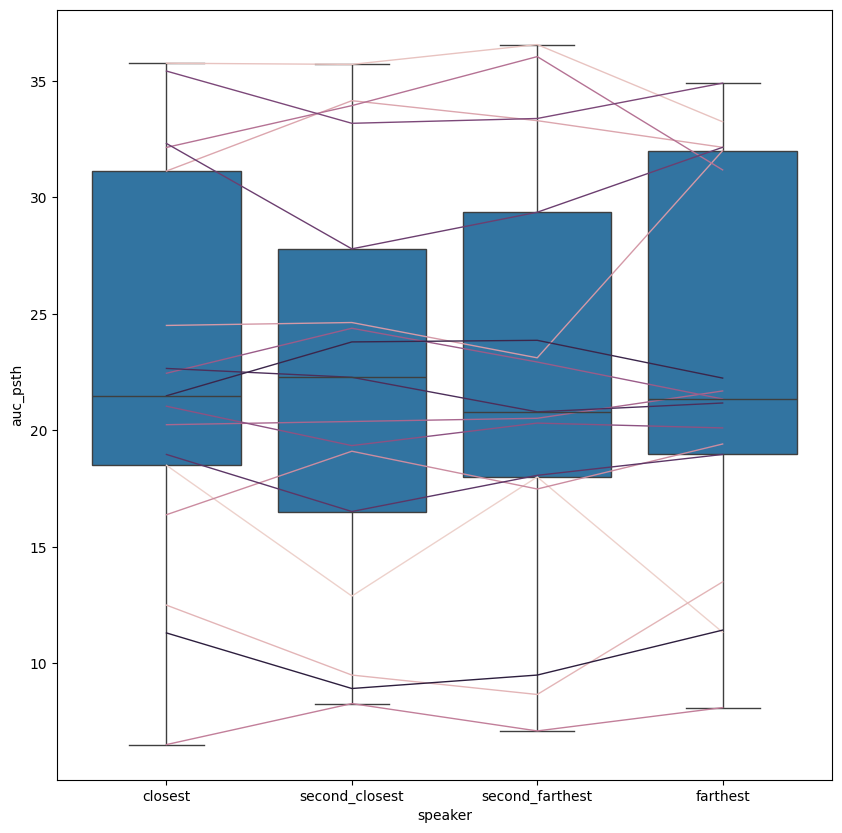

Friedman Test p: 0.9426619408668904
closest vs second_closest: corrected p = 0.8899688720703125
closest vs second_farthest: corrected p = 0.8899688720703125
closest vs farthest: corrected p = 0.8899688720703125
second_closest vs second_farthest: corrected p = 0.8899688720703125
second_closest vs farthest: corrected p = 0.8899688720703125
second_farthest vs farthest: corrected p = 0.8899688720703125


In [7]:
# peak fr for all soundsources
preferred = np.array(comb_table['HDAngle'])
speakers = np.array(list(speaker_position.values()))

# retrieve the cirular distance form the preferred direction to the speakers
diff = preferred[:, None] - speakers[None,:]
wrapped = (diff+180)%360-180
dist_deg = np.abs(wrapped)

# sort the relative distances so that the first column holds the smallest distance and the last column the furthest
idx_sorted = np.argsort(dist_deg, axis=1)
dist_sorted = np.take_along_axis(dist_deg, idx_sorted, axis=1)
# also sort the speakers so we don't lose track
speakers_sorted = np.take_along_axis(
    speakers[None,:], idx_sorted, axis=1
)
# retrieve the max response for each psth and sort as we did with the relative distance to the speakers
resp_peak_fr = np.array([
    np.max(new_rate[:,resp_window,i], axis=1) for i in range(0,4)
]).T
resp_peak_sorted = np.take_along_axis(resp_peak_fr, idx_sorted, axis=1)

fig, axes = plt.subplots(1,4, figsize=(14,3), sharey=True)

xlab = ['Closest', 'Second closest', 'second farthest', 'farthest']
for i, key in enumerate(speaker_position):
    axes[i].scatter(
        resp_peak_sorted[:,i],
        dist_sorted[:, i],
        s=10,
        alpha=0.7
    )
    axes[i].set_xlabel(xlab[i])
    if i == 0:
        axes[i].set_ylabel("Circular distance to speaker (deg)")

plt.tight_layout()
plt.show()



resp_peak_df = pd.DataFrame(resp_peak_fr, columns=list('awer'))
long_df = resp_peak_df.reset_index().melt(
    id_vars='index',
    var_name='speaker',
    value_name='max_psth'
)

plt.figure(figsize=(10,10))

sns.boxplot(
    data=long_df,
    x="speaker",
    y='max_psth',
    fliersize=0
    )

sns.lineplot(
    data=long_df,
    x="speaker",
    y="max_psth",
    hue="index",
    estimator=None,
    linewidth=1,
    alpha=0.6,
    legend=False
)

plt.xlabel("Speaker")
plt.ylabel("Max Psth")
plt.tight_layout()
plt.show()

# implement friedman test (non parametric Anova to compare the between the speaker responses but respecting the across within-cell pairing)
stat, p = friedmanchisquare(resp_peak_df['a'], resp_peak_df['w'], resp_peak_df['e'], resp_peak_df['r'])
print(stat, p)

# calculate the integral over the bins
auc_resp = (new_rate[:, resp_window, :] * time_bin).sum(axis=1)
auc_resp_df = pd.DataFrame(auc_resp, columns=['a', 'w', 'e', 'r']).reset_index().melt(id_vars='index', var_name='speaker', value_name='auc_psth')
auc_stat, auc_p = friedmanchisquare(auc_resp[:,0],auc_resp[:,1],auc_resp[:,2],auc_resp[:,3])
plt.figure(figsize=(10,10))
ax = sns.boxplot(data=auc_resp_df,x='speaker', y='auc_psth')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(speakers)
sns.lineplot(data=auc_resp_df, x='speaker', y='auc_psth', hue='index', linewidth=1, legend=False)
plt.show()
print(auc_stat, auc_p)

conds = [0,1,2,3]
auc_p_list = []

for c1, c2 in itertools.combinations(conds, 2):
    stat, p = wilcoxon(auc_resp[:, c1], auc_resp[:, c2])
    auc_p_list.append(p)

corrected_auc_p = false_discovery_control(auc_p_list)
for a in zip(itertools.combinations(speakers,2), corrected_auc_p):
    print(f"{a[0][0]} vs {a[0][1]}: corrected p = {a[1]}")

# do it again with the speakers sorted by distance to PD
auc_resp_sorted = np.take_along_axis(
    auc_resp, idx_sorted, axis=1
)
auc_resp_df_sort = pd.DataFrame(auc_resp_sorted, columns=['closest', 'second_closest', 'second_farthest', 'farthest']).reset_index().melt(id_vars='index', var_name='speaker', value_name='auc_psth')
plt.figure(figsize=(10,10))
ax = sns.boxplot(data=auc_resp_df_sort,x='speaker', y='auc_psth')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['closest', 'second_closest', 'second_farthest', 'farthest'])
sns.lineplot(data=auc_resp_df_sort, x='speaker', y='auc_psth', hue='index', linewidth=1, legend=False)
plt.show()

auc_stat, auc_p = friedmanchisquare(auc_resp_sorted[:,0],auc_resp_sorted[:,1],auc_resp_sorted[:,2],auc_resp_sorted[:,3])
print(f"Friedman Test p: {auc_p}")
auc_sort_p_list = []
for c1, c2 in itertools.combinations(conds, 2):
    stat, p = wilcoxon(auc_resp_sorted[:, c1], auc_resp_sorted[:, c2]) 
    auc_sort_p_list.append(p)

corrected_auc_sort_p = false_discovery_control(auc_sort_p_list)
for a in zip(itertools.combinations(['closest', 'second_closest', 'second_farthest', 'farthest'],2), corrected_auc_sort_p):
    print(f"{a[0][0]} vs {a[0][1]}: corrected p = {a[1]}")

In [8]:
#serve_cell_dashboard(
#    row_idx=0,
#    comb_table=comb_table,
#    new_rate=new_rate,
#    DIRECTIONS=DIRECTIONS,
#    speakers=["a", "w", "e", "r"],
#    speaker_position=speaker_position,
#    bins_plot=bins_plot,
#    time_bin=time_bin,
#    tmin=-100,
#    tmax=500,
#)

In [9]:
print(f"auc_resp: {auc_resp[0:10]}")
print(f"resp_peak: {resp_peak_fr[0:10]}")

auc_resp: [[18.         18.5        12.88888889 11.33333333]
 [35.75       36.55       33.23809524 35.7       ]
 [13.5         9.5        12.5         8.66666667]
 [31.125      34.14285714 32.14285714 33.28571429]
 [24.625      24.5        23.11111111 32.        ]
 [17.48275862 19.4137931  19.10344828 16.37931034]
 [ 8.10344828  8.27586207  6.51724138  7.10344828]
 [32.13793103 33.93103448 31.17241379 36.03448276]
 [20.51724138 21.68965517 20.37931034 20.24137931]
 [22.44827586 22.93103448 21.34482759 24.37931034]]
resp_peak: [[388.88888889 312.5        333.33333333 388.88888889]
 [400.         375.         380.95238095 325.        ]
 [500.         500.         750.         333.33333333]
 [375.         357.14285714 357.14285714 500.        ]
 [312.5        375.         277.77777778 250.        ]
 [189.65517241 224.13793103 206.89655172 189.65517241]
 [241.37931034 206.89655172 224.13793103 275.86206897]
 [379.31034483 327.5862069  413.79310345 396.55172414]
 [241.37931034 224.13793103 

In [10]:
print(comb_table.columns)

['Animal_Id', 'Cell_Id', 'hdRateSmooth', 'hdRateSmoothAlign', 'HDpeakFRsmooth', 'HDpeakFR', 'pValS', 'pValR', 'HDInx', 'nSpk', 'HDFR', 'HDAngle', 'halfwidth', 'peak2trough', 'waveform', 'RasterRows', 'RasterTimes', 'RasterRate', 'trigger_time', 'pupil_avg', 'whisk_avg', 'eye_avg', 'pupil_psth_a', 'pupil_psth_e', 'pupil_psth_r', 'pupil_psth_w', 'whisk_psth_a', 'whisk_psth_e', 'whisk_psth_r', 'whisk_psth_w', 'eye_psth_a', 'eye_psth_e', 'eye_psth_r', 'eye_psth_w']


In [11]:
print(f"Directions: {DIRECTIONS}")
print(f"Angles: {np.array(comb_table['HDAngle'])}")

Directions: [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150. 160. 170. 180. 190. 200. 210. 220. 230. 240. 250. 260. 270.
 280. 290. 300. 310. 320. 330. 340. 350. 360.]
Angles: [198.82180718  60.72329794 244.17083865 104.02076134 170.05774122
 325.11269538 253.4612033  102.99953625 321.09545129  74.45774444
 352.1692373   68.3164207   70.4786222   63.84641674  70.21464294
 348.81045161 218.5904144 ]


In [12]:
import numpy as np, pickle

cell_id = 4
i = int(np.where(comb_table["Cell_Id"].to_numpy() == cell_id)[0][0])

dbg = {
    "cell_id": int(cell_id),
    "directions": np.array(DIRECTIONS, float),     # your 0..360 step 10
    "hdRateSmooth": np.array(comb_table["hdRateSmooth"][i], float),
}

with open("debug_hd_cell4_python.pkl", "wb") as f:
    pickle.dump(dbg, f)

In [14]:
import numpy as np

# 1) get python list of arrays
hdr_list = comb_table["hdRateSmooth"].to_list()  # polars Series -> list

# 2) convert each entry to 1D float array
hdr_list = [np.asarray(x, dtype=float).ravel() for x in hdr_list]

# 3) enforce consistent length (36 or 37)
lengths = np.array([a.size for a in hdr_list])
print("hdRateSmooth lengths:", np.unique(lengths, return_counts=True))

# If you have mixed lengths, choose 37 if present, else 36
target_len = 37 if np.any(lengths == 37) else 36

# Pad/truncate to target_len (conservative)
hdr_list_fixed = []
for a in hdr_list:
    if a.size == target_len:
        hdr_list_fixed.append(a)
    elif a.size > target_len:
        hdr_list_fixed.append(a[:target_len])
    else:
        # pad with NaNs if too short
        b = np.full(target_len, np.nan, dtype=float)
        b[:a.size] = a
        hdr_list_fixed.append(b)

hd_rate_smooth_2d = np.vstack(hdr_list_fixed)  # (n_cells, target_len)

hdRateSmooth lengths: (array([37]), array([17]))


In [ ]:
from workbench.data.validate_process_pipe import validate, print_report
import numpy as np

report = validate(
    auc_resp=auc_resp,                       # (n_cells, 4)
    preferred_deg=preferred,                 # (n_cells,)
    speakers_deg=np.array([93,178,272,356]),
    directions_edges_deg=DIRECTIONS,         # (37,)
    hd_rate_smooth=hd_rate_smooth_2d,   # optional
    raster_rows=comb_table["RasterRows"],    # optional
    raster_times=comb_table["RasterTimes"],  # optional (not used yet)
    time_bin_s=time_bin,
    offsets_to_test=(-10, -5, 0, 5, 10),
)
print_report(report)

=== Pipeline Validation Report ===
n_cells: 17
speakers_deg: [93.0, 178.0, 272.0, 356.0]
time_bin_s: 0.002

Trial indexing / normalization:
  trial_index_min: 0.0
  trial_index_max: 29.0
  median_n_unique_trials: 30.0
  median_max_trial_index: 29.0
  suspicious max(rows) mismatch frac: 0.0

PD diagnostics:
  PD_edges vs PD_centers: median Δ=-5.00°, mean Δ=-5.00°
  ΔPD percentiles (5/25/50/75/95): [-5.0, -5.0, -5.0, -5.0, -5.0]
  Sensitivity to PD offsets (order change rates):
    offset -10.0°: any-order change 11.8%, closest change 5.9%
    offset -5.0°: any-order change 0.0%, closest change 0.0%
    offset +0.0°: any-order change 0.0%, closest change 0.0%
    offset +5.0°: any-order change 0.0%, closest change 0.0%
    offset +10.0°: any-order change 5.9%, closest change 5.9%

Sorted-AUC Friedman:
  chi2=0.388235, p=0.942662

Notes:
  - RasterRows include 0 → likely 0-based trial indexing present somewhere.
  - PD edge-vs-center: median Δ=-5.00° (IQR -5.00..-5.00).
